# MAE-эмбеддинги в регрессии глубины: MAE vs p5 / p5+d1

Проверяем, годятся ли латентные вектора self-supervised **Video-MAE**
(`embedding_extrator/01_MAE_variation`) как признаки для регрессии глубины —
в сравнении с TSR-признаками **p5** и **p5+d1**.

**Маршрут B (эмбеддинг как feature-dir, drop-in в thermo):**
1. энкодер MAE (checkpoint `mae_full.pt`) прогоняется по клипам каждого kaggle-видео;
2. токены `(880,256)` → reshape `(8,11,10,256)` → усреднение по времени → `(11,10,256)`,
   усреднение по клипам видео;
3. **PCA 256→32** по всем видео;
4. апсемпл `(32,11,10)`→`(32,176,160)` и укладка в кадр регрессии `(32,256,320)`
   на ROI `[35:211, 81:241]` (x+1 из-за `drop_first_col`) → `features_cache/mae_kaggle/`.

Дальше `mae` подключается в thermo как ещё один `features.kind` (deriv=`p5`,
каналы как есть, `in_channels=32`) — точно как tsr/fourier.

**Условия сравнения (равные):** muon + convnext_nano + 50 эпох, seed 67, crop 48,
**single-domain kaggle** (held-out видео). MAE обучался только на kaggle и на
ROI-кропе, поэтому кросс-домен (tpu) здесь не рассматриваем.

In [1]:
import sys, subprocess
from pathlib import Path
import numpy as np, torch
import matplotlib.pyplot as plt
ROOT = Path('/Users/tomatocoder/Documents/thermal-control-ya-project')
sys.path.insert(0, str(ROOT))
from thermo.config import CFG
from thermo.data.index import build_index_kaggle, split_by_video
from thermo.pipeline import make_loaders, make_loss, get_device
from thermo.models import build_model
from thermo.optimizers import build_optimizer
from thermo.engine import train_loop
from thermo.metrics import RegressionMetrics

# равные условия
CFG.optim.name = 'muon'; CFG.model.name = 'convnext_nano'
CFG.train.epochs = 50; CFG.regression.augment = False
dev = get_device()
print('device:', dev, '| optim:', CFG.optim.name, '| model:', CFG.model.name, '| epochs:', CFG.train.epochs)

device: mps | optim: muon | model: convnext_nano | epochs: 50


## 1. Признаки MAE → `features_cache/mae_kaggle/` (строится, если нет)

In [2]:
mae_dir = ROOT/'features_cache'/'mae_kaggle'
if len(list(mae_dir.glob('*.npy'))) < 38:
    print('строю MAE-фичи…')
    subprocess.run([sys.executable, str(ROOT/'embedding_extrator/01_MAE_variation/build_features_mae.py')], check=True)
print('mae features:', len(list(mae_dir.glob('*.npy'))), '| форма:', np.load(next(mae_dir.glob('*.npy'))).shape)

# покрытие ROI дефектными кропами (mae занулён вне ROI)
CFG.features.kind = 'tsr'
idx0 = build_index_kaggle(); s = CFG.crop.crop; Y0,Y1,X0,X1 = 35,211,81,241
inside = sum(1 for v,r0,c0,d,cl,dm in idx0 if Y0<=r0+s//2<Y1 and X0<=c0+s//2<X1)
print(f'дефектных кропов {len(idx0)} | центр в ROI: {inside} ({100*inside/len(idx0):.0f}%)')

mae features: 38 | форма: (32, 256, 320)
дефектных кропов 376 | центр в ROI: 347 (92%)


## 2. Сетка: mae vs p5 vs p5+d1 (single-domain kaggle)

In [3]:
def run_feature(kind, deriv, in_ch):
    CFG.features.kind = kind; CFG.features.deriv = deriv
    idx = build_index_kaggle()
    tr, te = split_by_video(idx, n_test=CFG.train.n_test_videos)
    torch.manual_seed(CFG.train.seed); np.random.seed(CFG.train.seed)
    train_ld, test_ld, t_mean, t_std = make_loaders(tr, te, task='regression')
    model = build_model('regression', in_ch).to(dev)
    loss_fn = make_loss('regression', tr).to(dev)
    opt = build_optimizer(model)
    train_loop(train_ld, model, loss_fn, opt, dev, 'regression', t_mean, t_std, val_loader=test_ld)
    dom = np.array([r[5] for r in te])
    return RegressionMetrics.from_loader(model, test_ld, dev, t_mean, t_std, domain=dom).by_domain()

GRID = [('mae','mae','p5',32), ('p5','tsr','p5',6), ('p5+d1','tsr','p5+d1',11)]
res = {}
for name, kind, deriv, ic in GRID:
    print(f'\n===== {name} (kind={kind}, deriv={deriv}, in_ch={ic}) =====')
    res[name] = run_feature(kind, deriv, ic)


===== mae (kind=mae, deriv=p5, in_ch=32) =====


[muon] params: muon-группа=1327840 adam-группа=13662481


epoch   1/50 | loss 0.4473 | mae_mm=5.5156 rmse_mm=6.5122


epoch   2/50 | loss 0.2960 | mae_mm=5.5859 rmse_mm=6.5111


epoch   3/50 | loss 0.2447 | mae_mm=6.2034 rmse_mm=7.4979


...

epoch  46/50 | loss 0.0015 | mae_mm=1.2994 rmse_mm=2.2785


epoch  47/50 | loss 0.0022 | mae_mm=1.3194 rmse_mm=2.2347


epoch  48/50 | loss 0.0022 | mae_mm=1.3340 rmse_mm=2.2847


epoch  49/50 | loss 0.0018 | mae_mm=1.2744 rmse_mm=2.1229


epoch  50/50 | loss 0.0019 | mae_mm=1.3085 rmse_mm=2.3386


## 3. Сравнение

=== single-domain kaggle (muon+convnext_nano, 50 эпох) ===


,mae_mm,rmse_mm,r2,medae_mm,acc_quant
feat,,,,,
mae,4.666,6.079,0.204,3.005,0.385
p5,1.171,1.968,0.917,0.810,0.923
p5+d1,1.309,2.339,0.882,0.728,0.879


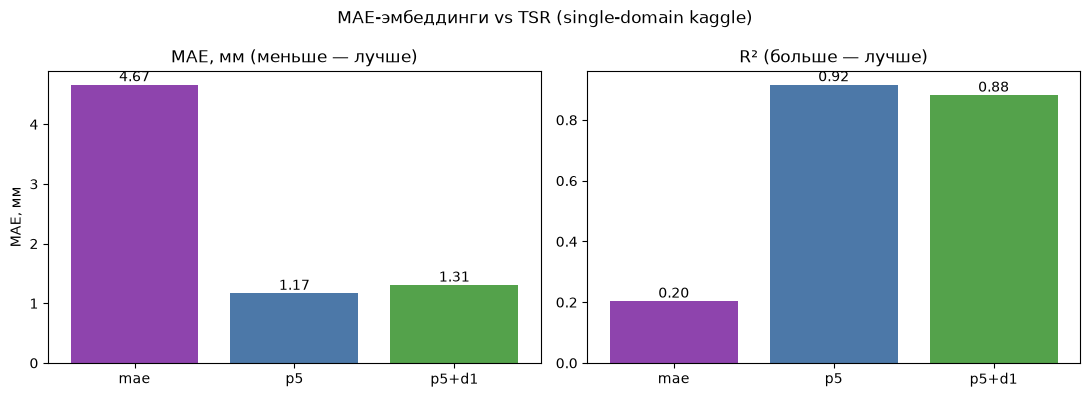

In [4]:
import pandas as pd
rows = [{'feat': n, **{k: round(v,3) for k,v in res[n]['kaggle'].items()}} for n in res]
df = pd.DataFrame(rows).set_index('feat')
cols = [c for c in ['mae_mm','rmse_mm','r2','medae_mm','acc_quant'] if c in df.columns]
print('=== single-domain kaggle (muon+convnext_nano, 50 эпох) ==='); display(df[cols])

names = list(res)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
cl = ['#8E44AD','#4C78A8','#54A24B']
ax[0].bar(names, [res[n]['kaggle']['mae_mm'] for n in names], color=cl)
ax[0].set_title('MAE, мм (меньше — лучше)'); ax[0].set_ylabel('MAE, мм')
for i,n in enumerate(names): ax[0].text(i, res[n]['kaggle']['mae_mm'], f"{res[n]['kaggle']['mae_mm']:.2f}", ha='center', va='bottom')
ax[1].bar(names, [res[n]['kaggle']['r2'] for n in names], color=cl)
ax[1].set_title('R² (больше — лучше)')
for i,n in enumerate(names): ax[1].text(i, res[n]['kaggle']['r2'], f"{res[n]['kaggle']['r2']:.2f}", ha='center', va='bottom')
fig.suptitle('MAE-эмбеддинги vs TSR (single-domain kaggle)')
plt.tight_layout(); plt.savefig(str(ROOT/'mae_vs_tsr_regression.png'), dpi=110); plt.show()

## 4. Выводы

_(заполняется по факту прогона)_

Ограничения: MAE-фичи покрывают ~92% дефектных кропов (ROI), остальные занулены;
чекпойнт промежуточный (не досошёлся); эмбеддинги сжаты PCA 256→32; MAE — только
kaggle (кросс-домен на tpu не поддержан без переноса препроцессинга).